# Rules Extraction for Knowledge Base Using Decision Trees.

In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn import tree as sklearn_tree
from sympy import sympify
import pickle
import os
from tqdm import tqdm
import random

rd_seed = 42

## Dataset Preparation



We use Breast Cancer Wisconsin (Diagnostic) dataset, which can be downloaded here: [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download)

Version of the dataset: 2

In [2]:
df = pd.read_csv('data.csv')

### Dataset split

Before even looking at data, we will split it into train-test sets:

In [3]:
print(f'Dataset size: {len(df)}')

Dataset size: 569


The dataset is small, thus, when splitting data we need test set larger. Also, using cross validation is highly important.

We will split dataset into 70%-30%

In [4]:
df_train, df_test = train_test_split(df, train_size=0.7, random_state=rd_seed)
print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')

Train shape: (398, 33)
Test shape: (171, 33)


After split we can inspect data in the `df_train`, figure out all transformations on df_train and create transformation function.

### First look on the data:

In [5]:
df_train.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
149,869931,B,13.74,17.91,88.12,585.0,0.07944,0.06376,0.02881,0.01329,...,22.46,97.19,725.9,0.09711,0.1824,0.1564,0.06019,0.2350,0.07014,NaN
124,865468,B,13.37,16.39,86.10,553.5,0.07115,0.07325,0.08092,0.02800,...,22.75,91.99,632.1,0.10250,0.2531,0.3308,0.08978,0.2048,0.07628,NaN
421,906564,B,14.69,13.98,98.22,656.1,0.10310,0.18360,0.14500,0.06300,...,18.34,114.10,809.2,0.13120,0.3635,0.3219,0.11080,0.2827,0.09208,NaN
195,875878,B,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,...,22.00,90.81,600.6,0.10970,0.1506,0.1764,0.08235,0.3024,0.06949,NaN
545,922576,B,13.62,23.23,87.19,573.2,0.09246,0.06747,0.02974,0.02443,...,29.09,97.58,729.8,0.12160,0.1517,0.1049,0.07174,0.2642,0.06953,NaN


There is the column `Unnamed: 32`, which has ony `nan` values. We will remove this column, because it has no value for us.

In [6]:
df_train_modified = df_train.drop(['Unnamed: 32'], axis=1)

In [7]:
df_train_modified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 149 to 102
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       398 non-null    int64  
 1   diagnosis                398 non-null    object 
 2   radius_mean              398 non-null    float64
 3   texture_mean             398 non-null    float64
 4   perimeter_mean           398 non-null    float64
 5   area_mean                398 non-null    float64
 6   smoothness_mean          398 non-null    float64
 7   compactness_mean         398 non-null    float64
 8   concavity_mean           398 non-null    float64
 9   concave points_mean      398 non-null    float64
 10  symmetry_mean            398 non-null    float64
 11  fractal_dimension_mean   398 non-null    float64
 12  radius_se                398 non-null    float64
 13  texture_se               398 non-null    float64
 14  perimeter_se             398 

- Almost all of the features are numeric.
- There are no missing values in the train data. In reality our classifier may get some missing values, that should be handled. But for simplification reasons for this task we will assume that there will be no missing values in the test set and in model usage.

In [8]:
df_t_m_nunique = pd.DataFrame(df_train_modified.nunique(), columns=['Number of unique values'])
df_t_m_nunique['Uniqueness ratio'] = np.round(df_t_m_nunique['Number of unique values'] / len(df), 3)
df_t_m_nunique.T

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
Number of unique values,398.000,2.000,338.000,349.000,375.000,380.000,346.000,380.000,387.00,384.000,...,334.000,361.000,367.000,383.000,316.000,378.000,383.000,350.000,368.000,380.000
Uniqueness ratio,0.699,0.004,0.594,0.613,0.659,0.668,0.608,0.668,0.68,0.675,...,0.587,0.634,0.645,0.673,0.555,0.664,0.673,0.615,0.647,0.668


Almost all numeric features have high uniqueness ratio.

Also let's look at some stats of the numeric features:

In [9]:
df_train_modified.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,3.980000e+02,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,...,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,3.012241e+07,14.176078,19.159171,92.256332,659.770854,0.095962,0.103303,0.088071,0.048440,0.180308,...,16.287322,25.505553,107.363844,881.848241,0.131772,0.249086,0.268497,0.113839,0.288300,0.083537
std,1.270358e+08,3.535730,4.214074,24.289529,358.865452,0.013766,0.051209,0.077836,0.037712,0.026871,...,4.799691,6.017564,33.083204,570.753903,0.023023,0.148622,0.196139,0.063886,0.062318,0.017518
min,8.915000e+03,7.691000,9.710000,48.340000,170.400000,0.062510,0.019380,0.000000,0.000000,0.116700,...,8.678000,12.020000,54.490000,223.600000,0.081250,0.034320,0.000000,0.000000,0.156500,0.055040
25%,8.682072e+05,11.752500,16.170000,75.805000,426.175000,0.085550,0.063407,0.029585,0.020692,0.161575,...,13.075000,21.070000,84.542500,521.550000,0.114325,0.147325,0.116475,0.063885,0.247775,0.071155
50%,9.053455e+05,13.275000,18.700000,85.980000,546.250000,0.094625,0.091280,0.061880,0.034110,0.178800,...,14.975000,25.155000,97.745000,687.600000,0.131150,0.209250,0.226200,0.099270,0.280750,0.080165
75%,8.813066e+06,16.090000,21.555000,105.625000,797.400000,0.104475,0.130575,0.127075,0.073963,0.195550,...,18.707500,29.410000,125.300000,1061.250000,0.146000,0.341600,0.384700,0.160400,0.315650,0.091745
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.311400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.218400,0.937900,0.903400,0.275600,0.663800,0.173000


We see that features are scaled differently. But for the decision trees scaling - like standardization or normalization are no necessary. Scaling will only reduce interpretability of the model, because the decision threshold values will be scaled too and thus it will be hard to interpret them in regard to original data.

Last thing we want to examine how our data is balanced:

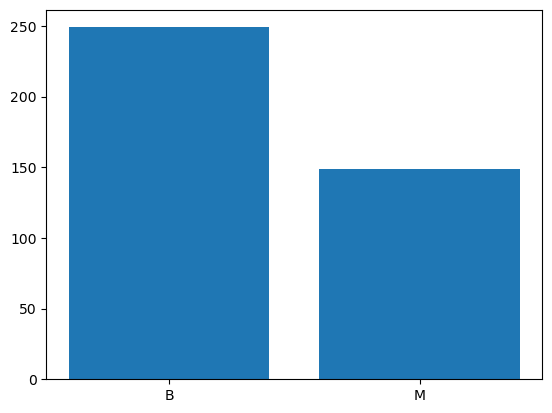

In [10]:
fig, ax = plt.subplots()
_ = ax.bar(x=df_train['diagnosis'].unique(),
           height=df_train['diagnosis'].value_counts())


In [11]:
df_t_diagnosis_vc = pd.DataFrame(df_train['diagnosis'].value_counts())
df_t_diagnosis_vc['count ratio (%)'] = np.round(df_t_diagnosis_vc['count'] / len(df_train) * 100, 2)
df_t_diagnosis_vc

,count,count ratio (%)
diagnosis,,
B,249,62.56
M,149,37.44


From the train set we see that there is some imbalance. Some up-sampling or under-sampling may make situation a little bit better, but for simplification, we will ignore such methods, as well as other dataset modifications to solve this issue.

But in training, we will use AUC score as a baseline metric. Additionally, we will also track F1 score and Accuracy.

### Data Transformation

In this section we will:
- make `diagnosis` label as category type
- create transformation function to separate class from features and make other transformations we did earlier.

In the following transformation function we will also fix feature names. Currently, there is an inconsistency, some names have words separated by space ` ` and some by underscore `_`. i.e. `concave points_worst`. This will also may help in rules parsing, because feature will be represented as a single word without any whitespaces.

In [12]:
def transform_and_split_data(dataframe) -> tuple[pd.DataFrame, pd.Series]:
    diagnosis_category = pd.api.types.CategoricalDtype(dataframe['diagnosis'].unique())
    dataframe['diagnosis'] = dataframe['diagnosis'].astype(diagnosis_category)
    dataframe_dropped = dataframe.drop(['id', 'Unnamed: 32'], axis=1)
    y_data = dataframe_dropped['diagnosis'].cat.codes
    X_data = dataframe_dropped.drop(['diagnosis'], axis=1)
    # fix feature name inconsistency
    fixed_feature_names = []
    for feature_name in X_data.columns:
        fixed_feature_names.append(str.replace(feature_name, ' ', '_'))
    X_data.columns = fixed_feature_names
    return X_data, y_data

In [13]:
X_train, y_train = transform_and_split_data(df_train)
X_test, y_test = transform_and_split_data(df_test)

Now our data is prepared for training.

## Model Training - Random Forest Decision Trees

We will try to train the best Random Forest with Decision Tree classifier:
- we will use cross validation to avoid great/poor fit by chance
- we will use randomized hyperparameter choice for faster training

### Training

For this task we will use very basic hyperparameters:

In [14]:
hyperparameters = {
    'n_estimators': np.append([1], np.arange(5, 105, 5)),
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(1, 31, 1),
}

In [15]:
param_grid = ParameterGrid(hyperparameters)
print('Number of hyperparameters: {}'.format(len(param_grid)))

Number of hyperparameters: 1260


We will do 100 random iterations, picking random parameters from the hyperparameter space. Because we have parameters as list and not as distributions, sampling without replacement will be used.

In [32]:
scoring = {'AUC': make_scorer(roc_auc_score),
           'Accuracy': make_scorer(accuracy_score),
           'F1_score': make_scorer(f1_score)}
hparam_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=rd_seed),
                                   param_distributions=hyperparameters,
                                   random_state=rd_seed, scoring=scoring, refit='AUC', n_iter=100)

Training may take a long time, use pickled training results in the next cell after the cell below.

In [36]:
results = hparam_search.fit(X_train, y_train)

Save or load results with pickle:

In [45]:
resave = False
if not resave and 'results' not in locals() and os.path.exists('pickle/training_results.pkl'):
    results = pickle.load(open('pickle/training_results.pkl', 'rb'))
elif 'results' in locals():
    pickle.dump(results, open('pickle/training_results.pkl', 'wb'))
else:
    print('Could not save or load training_results.pkl')

In [48]:
best_hparam_idx = np.argmax(results.cv_results_['mean_test_AUC'])
print(f'Best model hyperparameters (validation): {results.cv_results_["params"][best_hparam_idx]}')
print(f'Best model mean AUC score (validation): {results.cv_results_["mean_test_AUC"][best_hparam_idx]:.3f}')
print(f'Best model mean F1 score (validation): {results.cv_results_["mean_test_F1_score"][best_hparam_idx]:.3f}')
print(f'Best model mean Accuracy (validation): {results.cv_results_["mean_test_Accuracy"][best_hparam_idx]:.3f}')

Best model hyperparameters (validation): {'n_estimators': 90, 'max_depth': 19, 'criterion': 'entropy'}
Best model mean AUC score (validation): 0.953
Best model mean F1 score (validation): 0.945
Best model mean Accuracy (validation): 0.960


### Model Evaluation
Now we will train model with best hyperparameters on whole train set and evaluate it on the test set.

The final model will be used for model extraction.

In [49]:
best_hparams = results.best_params_
print(f'Best parameters: ', best_hparams)

Best parameters:  {'n_estimators': 90, 'max_depth': 19, 'criterion': 'entropy'}


In [50]:
best_model = RandomForestClassifier(**best_hparams, random_state=rd_seed)
best_model.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=19, n_estimators=90,
                       random_state=42)

In [51]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

scoring = {
    'AUC': roc_auc_score(y_test, y_pred_proba),
    'F1_score': f1_score(y_test, y_pred),
    'Accuracy': accuracy_score(y_test, y_pred)

}

for metric, value in scoring.items():
    print(f"Test set {metric}: {value:.3f}")

Test set AUC: 0.997
Test set F1_score: 0.959
Test set Accuracy: 0.971


We see that on test set we have better metrics than on the cross validation. We can assume that on other test data our model will perform with similar performance as on the cross validation, if not slightly better.

## Rules Extraction and Evaluation with RF+HC Algorithm

Now we have extract rules from our random forest.


We will follow approach and algorith presented in paper Rule Extraction from Random Forest: the RF+HC Methods (Morteza Mashayekhi and Robin Gras 2024):

![](images/algorithm_rf_hc.png)


We have 90 trees in our best model, with max depth of 19. The model will have quite a lot of rules, making its interpretability very complex.

### Examining Sklearn Trees Structure
In order to extract something from the trees, we have to understand how to work with sklearn tree structure in the first place.


Documentation resources can be found here:
- [Decision Tree Classifier](https://scikit-learn.org/1.5/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [Tree Structure](https://scikit-learn.org/1.5/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py)

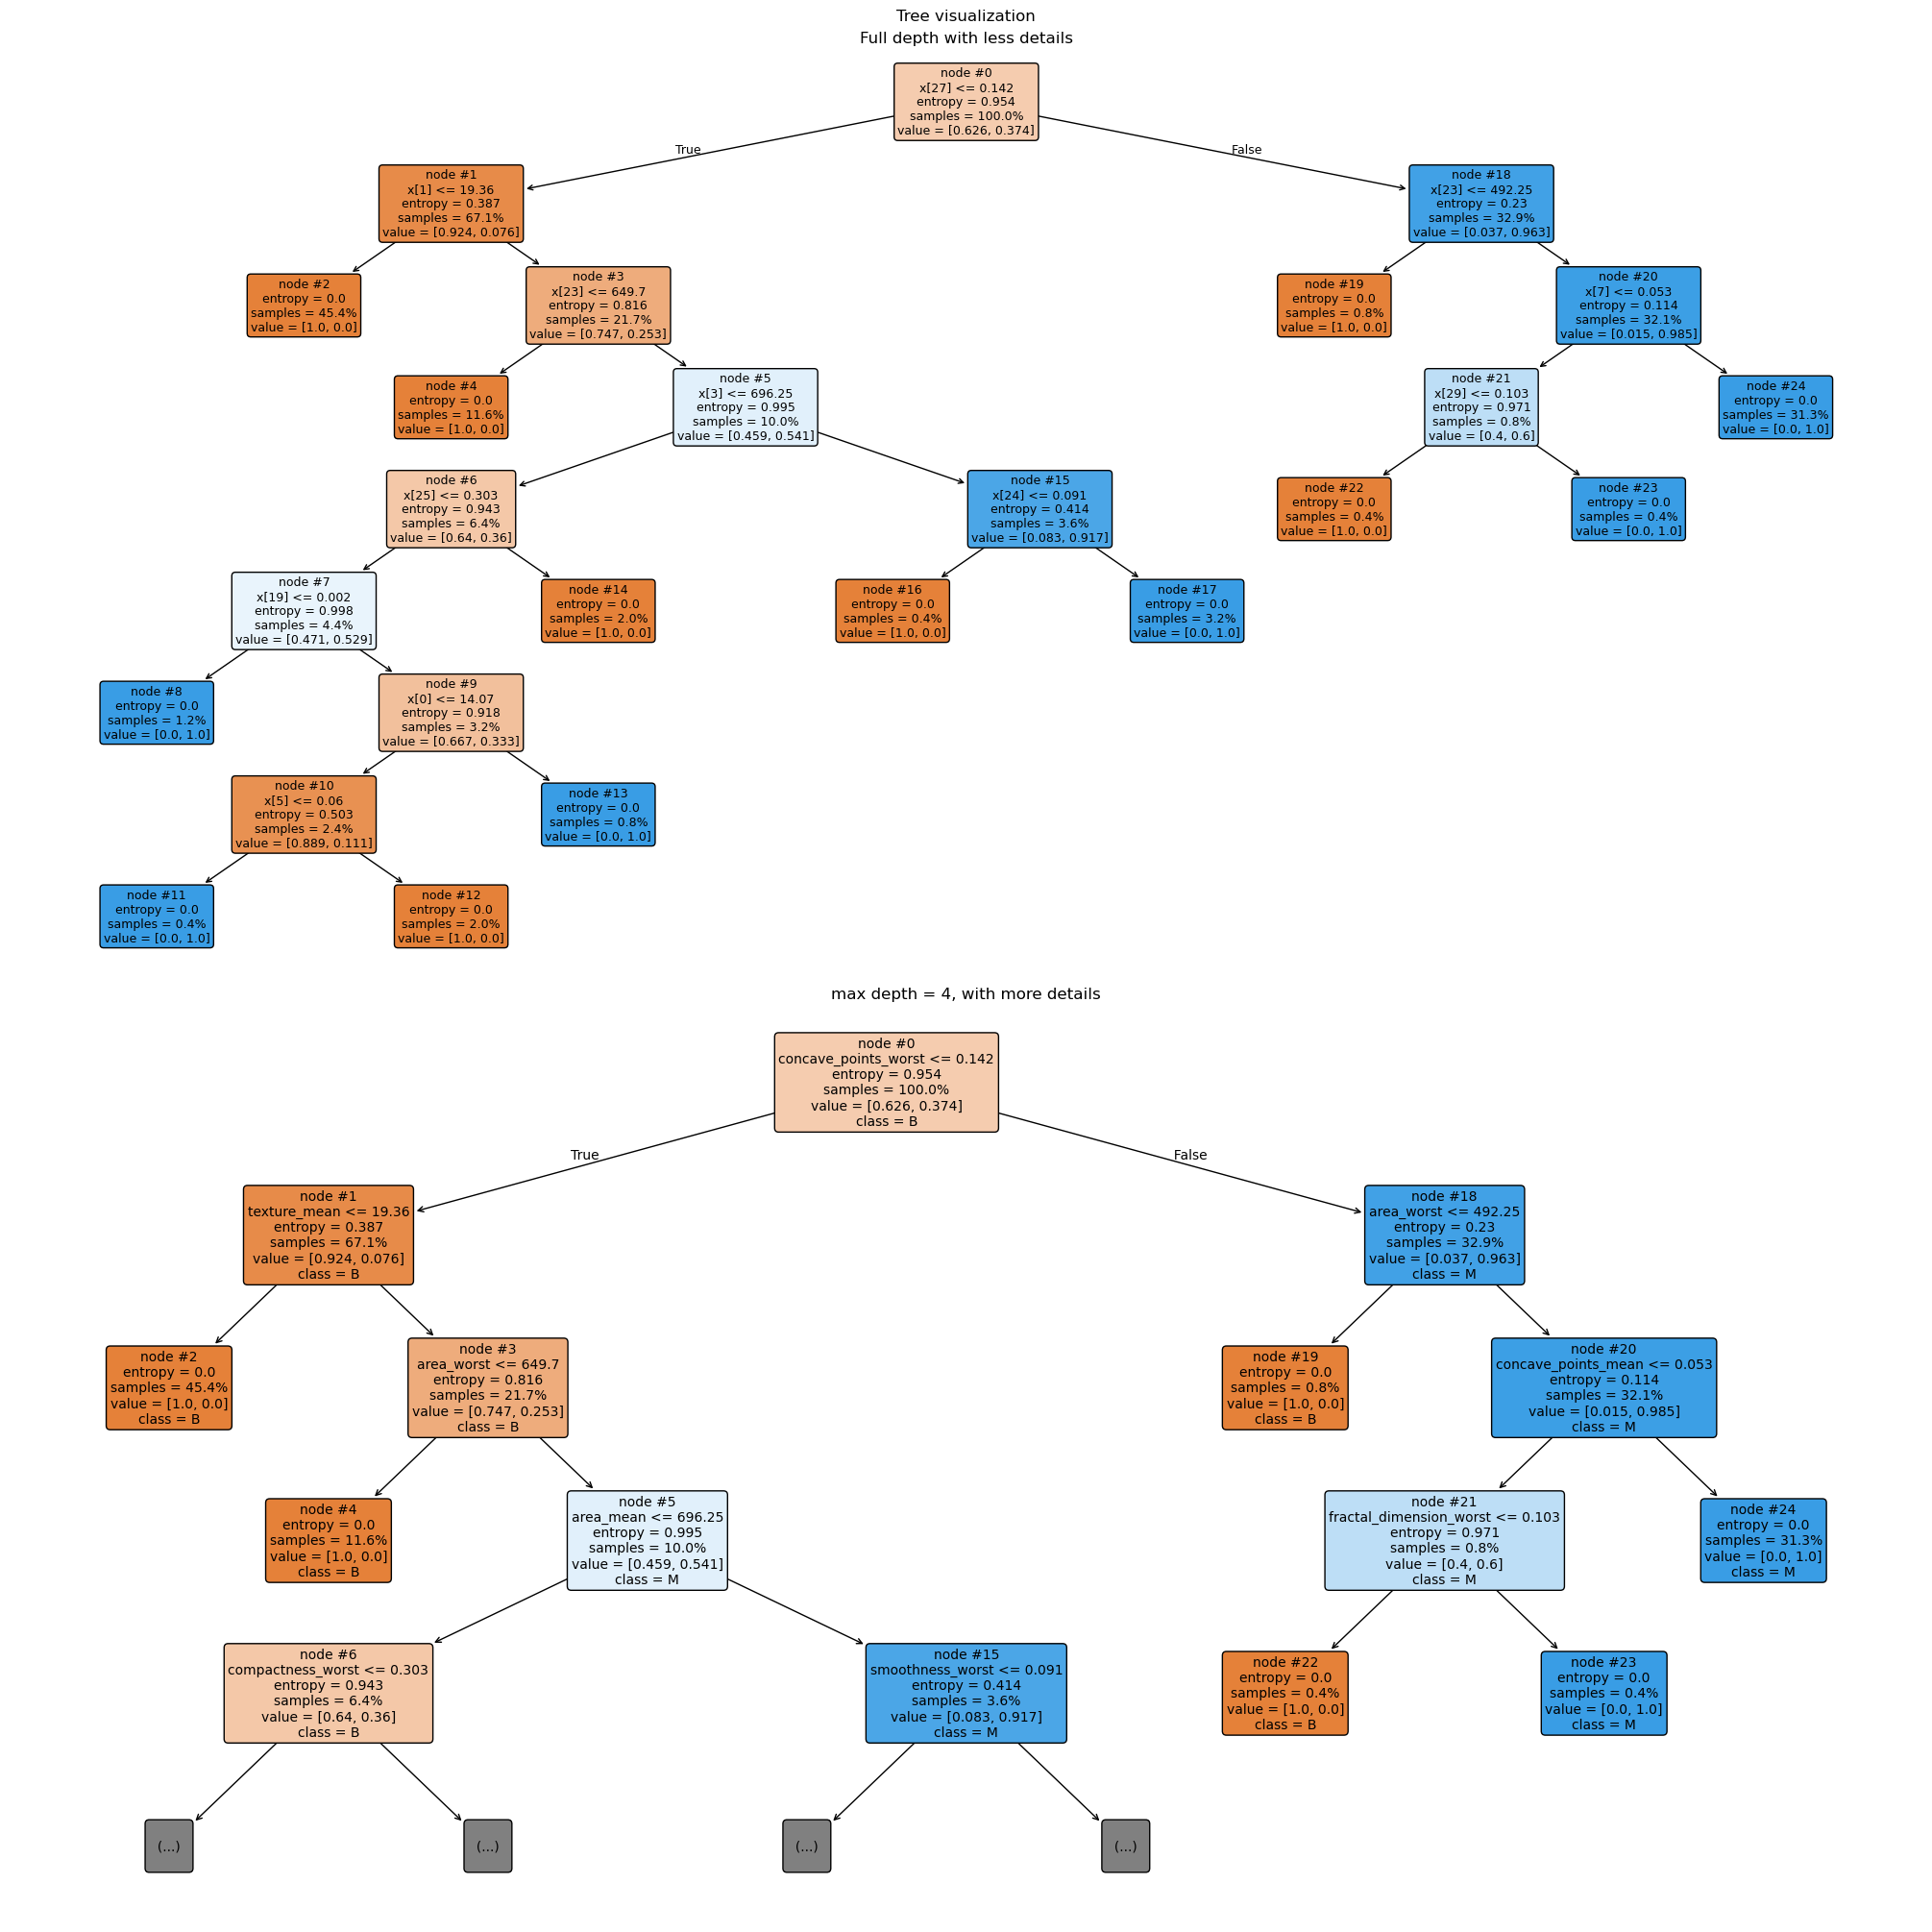

In [53]:
estimators = best_model.estimators_
tree = estimators[0]
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 20), constrained_layout=True)
# bigger tree
ax_bigger_tree_plot = axes[0]
sklearn_tree.plot_tree(tree,
                       node_ids=True,
                       filled=True,
                       proportion=True,
                       rounded=True,
                       fontsize=9,
                       ax=ax_bigger_tree_plot)
ax_bigger_tree_plot.set_title('Full depth with less details')

# smaller tree with more details
ax_smaller_tree_plot = axes[1]
sklearn_tree.plot_tree(tree,
                       max_depth=4,
                       feature_names=X_train.columns,
                       class_names=df_train['diagnosis'].unique(),
                       node_ids=True,
                       filled=True,
                       proportion=True,
                       rounded=True,
                       fontsize=10,
                       ax=ax_smaller_tree_plot)
ax_smaller_tree_plot.set_title('max depth = 4, with more details')
_ = fig.suptitle('Tree visualization')

Nodes have indexes. Root index is 0.

From documentation we can access node information using these functions:

> - `children_left[i]`: id of the left child of node i or -1 if leaf node
> - `children_right[i]`: id of the right child of node i or -1 if leaf node
> - `feature[i]`: feature used for splitting node i
> - `threshold[i]`: threshold value at node i
> - `n_node_samples[i]`: the number of training samples reaching node i
> - `impurity[i]`: the impurity at node i
> - `weighted_n_node_samples[i]`: the weighted number of training samples reaching node i
> - `value[i, j, k]`: the summary of the training samples that reached node i for output j and class k (for regression tree, class is set to 1). See below for more information about value.

Extraction of all information of the node 0:

In [54]:
node_id = 0
classes = df_train['diagnosis'].unique()
print(f'node #{node_id}')
print(f'{X_train.columns[tree.tree_.feature[node_id]]} <= {tree.tree_.threshold[node_id]}')
print(f'gini = {tree.tree_.impurity[node_id]}')
print(f'samples = {tree.tree_.n_node_samples[node_id]}')
value = np.squeeze(tree.tree_.value[0])
print(f'value = {value}')
print(f'class = {np.argmax(value)} ({classes[np.argmax(value)]})')
print(f'is split node = {tree.tree_.children_left[node_id] != tree.tree_.children_right[node_id]}')

node #0
concave_points_worst <= 0.14239999651908875
gini = 0.9539698702074323
samples = 249
value = [0.62562814 0.37437186]
class = 0 (B)
is split node = True


If we have a leaf node, both left and right child are `-1`:

In [55]:
node_id = 2
print(f'Node #{node_id} (leaf node) left child: {tree.tree_.children_left[node_id]}')
print(f'Node #{node_id} (leaf node) right child: {tree.tree_.children_right[node_id]}')

Node #2 (leaf node) left child: -1
Node #2 (leaf node) right child: -1


### Extracting Rules From a Tree

In this section we will create an algorithm to extract all rules from a single tree.

We will traverse a tree using stack, and each time we get to a list, we generate a rule from the tree.

In [88]:
if sympify('3 <= 4'):
    print('bla')

bla


In [96]:
class Rule:
    def __init__(self, premise, consequent_name, consequent_code):
        self.premise = premise
        self.consequent_name = consequent_name
        self.consequent_code = consequent_code

    def match(self, sample) -> bool:
        for predicate in self.premise:
            feature_term, operation_symbol, value_term = predicate
            sample_value = sample[feature_term]
            is_true = sympify(f'{sample_value} {operation_symbol} {value_term}')
            if not is_true:
                return False
        return True

    def __str__(self):
        predicates_str = []
        for predicate in self.premise:
            feature_term, operation_symbol, value_term = predicate
            predicate_str = f'{feature_term} {operation_symbol} {value_term}'
            predicates_str.append(predicate_str)
        premise_str = ' & '.join(predicates_str)
        return f'IF {premise_str} THEN {self.consequent_name}'

    @property
    def consequent(self):
        return self.consequent_name

In [75]:
class RuleExtractionIterator:
    def __init__(self, decision_tree, feature_names, class_names):
        """
        :param decision_tree: a trained DecisionTreeClassifier
        :param feature_names: list of feature names
        """
        self.tree = decision_tree.tree_
        if self.tree.node_count == 0:
            return
        self.children_left = self.tree.children_left
        self.children_right = self.tree.children_right
        self.features = self.tree.feature
        self.thresholds = self.tree.threshold
        self.values = self.tree.value
        self.feature_names = feature_names
        self.class_names = class_names

    def __iter__(self):
        # Stack for DFS: each element is (node_id, path_conditions)
        # path_conditions is a list of tuples (feature, operator, threshold)
        if self.tree.node_count == 0:
            raise StopIteration
        self.stack = [(0, [])]
        return self

    def __next__(self):
        """
        Iteratively traverse the tree using a stack.
        When a leaf node is encountered, construct and return the rule.
        """
        while self.stack:
            current_node, current_path_conditions = self.stack.pop()

            if self.is_leaf_node(current_node):
                # Determine the predicted class at this leaf
                # self.values[node_id] has shape (1, n_classes) for single-output classification
                class_values = self.values[current_node][0]
                predicted_class_idx = np.argmax(class_values)
                predicted_class = self.class_names[predicted_class_idx]

                if current_path_conditions:
                    return Rule(current_path_conditions.copy(), predicted_class, predicted_class_idx)
                else:
                    return Rule(['TRUE'], predicted_class, predicted_class_idx)
            else:

                feature_idx = self.features[current_node]
                threshold_val = self.thresholds[current_node]

                # Condition for the left child (<= threshold)
                left_condition = (self.feature_names[feature_idx], "<=", threshold_val)

                # Condition for the right child (> threshold)
                right_condition = (self.feature_names[feature_idx], ">", threshold_val)

                # Add child nodes to stack
                # Note: We push the right child first so that the left child is popped next (DFS order).
                self.stack.append(
                    (self.children_right[current_node], current_path_conditions + [right_condition])
                )
                self.stack.append(
                    (self.children_left[current_node], current_path_conditions + [left_condition])
                )

        # If the stack is empty, we've traversed all leaves => no more rules
        raise StopIteration

    def is_leaf_node(self, node_idx) -> bool:
        """Leaf detection in sklearn (both children are -1)"""
        return self.children_left[node_idx] == -1 and self.children_right[node_idx] == -1


In [97]:
def print_decision_tree_rules(decision_tree, feature_names, class_names):
    for rule in RuleExtractionIterator(decision_tree, feature_names, class_names):
        print(rule)

We will use following feature names and class names for the rest of the notebook:

In [65]:
feature_names = X_train.columns
class_names = df_train['diagnosis'].unique()

In [98]:
print_decision_tree_rules(tree, feature_names, class_names)

IF concave_points_worst <= 0.14239999651908875 & texture_mean <= 19.359999656677246 THEN B
IF concave_points_worst <= 0.14239999651908875 & texture_mean > 19.359999656677246 & area_worst <= 649.6999816894531 THEN B
IF concave_points_worst <= 0.14239999651908875 & texture_mean > 19.359999656677246 & area_worst > 649.6999816894531 & area_mean <= 696.25 & compactness_worst <= 0.30274999141693115 & fractal_dimension_se <= 0.0019120000069960952 THEN M
IF concave_points_worst <= 0.14239999651908875 & texture_mean > 19.359999656677246 & area_worst > 649.6999816894531 & area_mean <= 696.25 & compactness_worst <= 0.30274999141693115 & fractal_dimension_se > 0.0019120000069960952 & radius_mean <= 14.070000171661377 & compactness_mean <= 0.06045500002801418 THEN M
IF concave_points_worst <= 0.14239999651908875 & texture_mean > 19.359999656677246 & area_worst > 649.6999816894531 & area_mean <= 696.25 & compactness_worst <= 0.30274999141693115 & fractal_dimension_se > 0.0019120000069960952 & radius

If we compare rules with visualizations above, we will see that the printed rules correspond to the tree structure.

Let's finish the step with extraction of all rules from every tree we have:


In [110]:
rules = []
for estimator in best_model.estimators_:
    rules.extend(RuleExtractionIterator(estimator, feature_names, class_names))

print(f'Number of rules: {len(rules)}')

Number of rules: 1425


### Computing Rules Coverage and Scores

In this section we will perform the Step 2 from the RF+HC algorithm.

In [162]:
train_samples_size = len(X_train)
rules_size = len(rules)

rules_coverage = np.full((train_samples_size, rules_size), -1, dtype=np.int8)

Filling in rules coverage matrix:

The default value is `-1`, because we cannot use `0` as it is a code value for one of the two classes. Thus, we have following range of values:
- `-1`: default value, premise of the rule is False
- `0`: premise is True, rule implicates class `0` (B)
- `1`: premise is True, rule implicates class `1` (M)

Computation time is quite expensive, because we have a matrix 398 x 1425 = 567150 rules evaluations. We will save the matrix using pickle, see the next cell after this cell below.

In [165]:
for sample_idx in tqdm(range(train_samples_size)):
    row = X_train.iloc[sample_idx]
    for rule_idx in range(rules_size):
        rule = rules[rule_idx]
        if rule.match(row):
            rules_coverage[sample_idx, rule_idx] = rule.consequent_code

100%|██████████| 398/398 [11:44<00:00,  1.77s/it]


In [291]:
resave = False
if not resave and 'rules_coverage' not in locals() and os.path.exists('pickle/rules_coverage.pkl'):
    rules_coverage = pickle.load(open('pickle/rules_coverage.pkl', 'rb'))
elif resave and 'rules_coverage' in locals():
    pickle.dump(rules_coverage, open('pickle/rules_coverage.pkl', 'wb'))
else:
    print('Could not save or load rules_coverage.pkl')

In [292]:
print('10 x 10 cut of the rules coverage matrix:')
rules_coverage[:10, :10]

10 x 10 cut of the rules coverage matrix:


array([[ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1,  0, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1,  1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1]], dtype=int8)

Computing rules scores on the whole coverage matrix:

In [215]:
def evaluate_rules_scores(rules_coverage_matrix, y_true, k=4):
    rule_scores = []
    rules_size = rules_coverage_matrix.shape[1]
    for rule_idx in range(rules_size):
        rule_column = rules_coverage_matrix[:, rule_idx]
        covered_mask = rule_column != -1
        covered_samples = rule_column[covered_mask]
        covered_y_true = y_true[covered_mask]
        cc = np.sum(covered_samples == covered_y)  # correct classifications
        ic = covered_samples.size - cc  # incorrect classifications
        if covered_samples.size == 0:
            print('no covered samples')
        rule_score = (cc - ic) / (cc + ic) + cc / (ic + k)
        rule_scores.append(rule_score)
    return rule_scores

In [216]:
rule_scores = evaluate_rules_scores(rules_coverage, y_train)
print('First 5 rules scores:')
print(rule_scores[:5])
print(f'Best score: {np.max(rule_scores)}')
print(f'Worst score: {np.min(rule_scores)}')

First 5 rules scores:
[18.534065934065936, 13.5, 0.7, 1.25, 2.3777777777777778]
Best score: 47.75
Worst score: -0.475


### Hill Climbing for Best Rules Set Selection

In this section we will perform Step 4 from RF + HC algorithm.

First step - we need to select initial rules, picking values with higher score with more probability.

In [266]:
def get_rules_idxs_set(rule_scores, initial_rules_number):
    if len(rules) < initial_rules_number:
        raise ValueError('initial_rules_number cannot exceed the number of available rules.')
    selected_rules_set: set = set(
        random.choices(population=np.arange(len(rule_scores)), weights=rule_scores, k=initial_rules_number))
    return selected_rules_set

In [267]:
def predict_proba(selected_rules_set, rules_coverage_matrix):
    selected_rules_coverage = rules_coverage_matrix[:, list(selected_rules_set)]
    y_pred_proba = []
    for sample in selected_rules_coverage:
        covering_rules = sample[sample != -1]
        if covering_rules.size == 0:  # all evaluations are -1, the sample cannot be predicted.
            sample_pred_proba = np.array([0.5, 0.5])
        else:
            sample_pred_proba = np.array([
                np.sum(covering_rules == 0) / covering_rules.size,
                np.sum(covering_rules == 1) / covering_rules.size,
            ])
        y_pred_proba.append(sample_pred_proba)
    y_pred_proba = np.array(y_pred_proba)
    return y_pred_proba


def rules_accuracy(selected_rules_set, rules_coverage_matrix, y_true):
    y_pred_proba = predict_proba(selected_rules_set, rules_coverage_matrix)
    threshold = 0.5
    y_pred = (y_pred_proba[:, 1] >= threshold).astype(int)
    return accuracy_score(y_true=y_true, y_pred=y_pred)


def rules_f1_score(selected_rules_set, rules_coverage_matrix, y_true):
    y_pred_proba = predict_proba(selected_rules_set, rules_coverage_matrix)
    threshold = 0.5
    y_pred = (y_pred_proba[:, 1] >= threshold).astype(int)
    return f1_score(y_true=y_true, y_pred=y_pred)


def rules_roc_auc_score(selected_rules_set, rules_coverage_matrix, y_true):
    y_pred_proba = predict_proba(selected_rules_set, rules_coverage_matrix)
    return roc_auc_score(y_true=y_true, y_score=y_pred_proba[:, 1])


We will use stochastic hill climbing, as in the paper.

It is not specified clearly, what heuristic function we should use:

> The hill climbing algorithm, searches for the best neighbor, the one with the highest score, of the current location based on equation (1) in the search space and by changing (adding/removing) one rule to the current rule set.

The equation (1):

> ruleScore1 = (cc − ic) /  (cc + ic) + cc / (ic + k) (1)

Two the most obvious approaches can come in mind:
1) pick a random rule using `rule_scores` as weights and add/remove from current rules state.
2) get all neighbor states by adding and removing one of the rules, compute state rule score, sum it up and that will be the value of the heuristic function. Then just sample one of the ranomd states given its total rule score as a weight. This approach looks better regarding searching the best rules state.

In [298]:
def hill_climbing(start_rules_idxs_set, rule_scores, score_fn, rules_coverage_matrix, y_true):
    current_state = start_rules_idxs_set
    while True:
        new_rule_idx = random.choices(population=np.arange(len(rule_scores)), weights=rule_scores, k=1)[0]
        neighbor_state = current_state.copy()
        if new_rule_idx in current_state:
            continue
        else:
            neighbor_state.add(new_rule_idx)
        neighbor_state_score = score_fn(neighbor_state, rules_coverage_matrix, y_true)
        current_state_score = score_fn(current_state, rules_coverage_matrix, y_true)
        if neighbor_state_score <= current_state_score:
            return current_state
        current_state = neighbor_state

In [269]:
# we will take square root of all rules number as initial rules number
initial_rules_number = int(np.sqrt(len(rules)))
print(f'Initial rules number: {initial_rules_number}')

Initial rules number: 37


In paper it is not specified how accuracy function should look like, given that we need to handle rules coverage. Also, it is not mentioned clearly, if we have to use `rule_scores` in computing accuracy metric. Because `rule_scores` range of values doesn't lie in interval [0, 1.0], and can even get negative values, it cannot be used as accuracy metric. Thus, `rule_scores` will be used only as weights in random sampling.

Because our dataset is imbalanced, we will use f1 score as main score/metric function instead of accuracy.

In [300]:
random.seed(rd_seed)
initial_rules_idxs_set = get_rules_idxs_set(rule_scores, initial_rules_number)
current_rules_idxs_set = best_rules_idxs_set = initial_rules_idxs_set
max_iterations = 500
for iteration in tqdm(range(max_iterations), desc='Iterations'):
    current_rules_idxs_set = hill_climbing(current_rules_idxs_set, rule_scores, rules_f1_score, rules_coverage, y_train)
    current_rules_score = rules_f1_score(current_rules_idxs_set, rules_coverage, y_train)
    best_rules_score = rules_f1_score(best_rules_idxs_set, rules_coverage, y_train)
    if current_rules_score > best_rules_score:
        best_rules_idxs_set = current_rules_idxs_set
    current_rules_idxs_set = get_rules_idxs_set(rule_scores, initial_rules_number)
best_rules = [rules[rule_idx] for rule_idx in best_rules_idxs_set]

Iterations:   0%|          | 1/500 [04:28<37:12:56, 268.49s/it]


KeyboardInterrupt: 

In [287]:
print(f'Number of rules: {len(best_rules)}')
print(f'AUC score on best rules set (train): {rules_roc_auc_score(best_rules_idxs_set, rules_coverage, y_train):.3f}')
print(f'F1 score on best rules set (train): {rules_f1_score(best_rules_idxs_set, rules_coverage, y_train):.3f}')
print(f'Accuracy on best rules set (train): {rules_accuracy(best_rules_idxs_set, rules_coverage, y_train):.3f}')

Number of rules: 36
AUC score on best rules set (train): 0.990
F1 score on best rules set (train): 0.987
Accuracy on best rules set (train): 0.990


In [288]:
print('Rules:')
print(*best_rules, sep='\n')

Rules:
IF concave_points_worst <= 0.14239999651908875 & texture_mean > 19.359999656677246 & area_worst <= 649.6999816894531 THEN B
IF area_worst <= 865.6999816894531 & smoothness_mean > 0.11540000140666962 & concave_points_mean > 0.05485999956727028 & fractal_dimension_se > 0.010344000067561865 THEN B
IF radius_worst <= 16.789999961853027 & concavity_worst <= 0.3888999968767166 & concave_points_worst <= 0.1449499949812889 & compactness_mean > 0.06691499799489975 THEN B
IF concavity_mean <= 0.09150499850511551 & perimeter_se <= 3.1855000257492065 & area_worst > 893.6499938964844 & concavity_se <= 0.024664999917149544 & smoothness_se <= 0.003068499965593219 THEN M
IF concave_points_worst > 0.12879999727010727 & texture_worst > 27.454999923706055 THEN M
IF concave_points_mean > 0.05127999931573868 & area_mean > 676.2999877929688 & concavity_worst > 0.1959500014781952 THEN M
IF concave_points_mean > 0.05127999931573868 & perimeter_worst > 115.89999771118164 THEN M
IF concavity_worst > 0.21

## Best Rules Evaluation

In this section we will perform the last Step 4 of the RF + HC algorithm, evaluating best rules set.

We will use 3 metrics (allowing us to compare this method to classical RF):
- AUC score to address issue with imbalanced dataset and evaluate its performance at every threshold.
- F1 score to address issue with imbalanced dataset.
- Accuracy, as it is a standard metric and is proposed in the paper.

In [294]:
test_samples_size = len(X_test)
best_rules_size = len(best_rules)
test_rules_coverage = np.full((test_samples_size, best_rules_size), -1, dtype=np.int8)

for sample_idx in tqdm(range(test_samples_size)):
    row = X_test.iloc[sample_idx]
    for rule_idx in range(best_rules_size):
        rule = best_rules[rule_idx]
        if rule.match(row):
            test_rules_coverage[sample_idx, rule_idx] = rule.consequent_code

100%|██████████| 171/171 [00:07<00:00, 22.37it/s]


In [297]:
print(f'AUC score on best rules set (test): {rules_roc_auc_score(np.arange(len(best_rules)), test_rules_coverage, y_test):.3f}')
print(f'F1 score on best rules set (test): {rules_f1_score(np.arange(len(best_rules)), test_rules_coverage, y_test):.3f}')
print(f'Accuracy on best rules set (test): {rules_accuracy(np.arange(len(best_rules)), test_rules_coverage, y_test):.3f}')

AUC score on best rules set (test): 0.974
F1 score on best rules set (test): 0.944
Accuracy on best rules set (test): 0.959


Our random forest had following test metrics:
- Test set AUC: 0.997
- Test set F1_score: 0.959
- Test set Accuracy: 0.971

We see that rules extraction algorithm has better AUC but worse F1 and Accuracy scores. In general it gives very similar results in comparison to random forests, which is surprising, because in forest we had more than 1000 rules, but here only 36, which makes this algorithm faster, trading off precision and recall metrics.


## What can be improved


- Understand dataset domain to make better data preprocessing using some domain knowledge, than just following numbers.
- Handle potential problems with data imbalance.
- Handle potential problems with missing values in input data in production.
- In hyperparameter search, try to use distributions skewed to lower amounts of estimators and max depth (or at least max depth, to make rule more interpretable) to sample trees that are more interpretable, so the rules are also interpretable.
- Following other better practices mentioned in the paper.